### 1. k-NN retrieval in embedding space (high priority, low effort)

Replace the SVM with a **k-NN classifier directly in SimCLR embedding space**. This is the most strategically important test because:

- It directly validates whether the embedding space encodes TF×condition identity without any downstream training
- It is **training-free for new classes** — this is your answer to the 200+ TF problem. You don't retrain a new SVM for each new TF; you just add labelled examples to the reference library and query against them
- It gives you a **retrieval capability**: given an unannotated trace from a new experiment, return the top-k most similar labelled traces with their TF×condition identities
- Low effort: swap `SVC` for `KNeighborsClassifier` in the existing IY031 notebooks

In [ ]:
import re
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pycatch22
import torch
from pathlib import Path
from matplotlib.patches import Patch
from IPython.display import display
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
# from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("/home/ianyang/stochastic_simulations/src").resolve()))
from models.ssl_transformer import SSL_Transformer

RANDOM_STATE = 42

# Fixed 6-class selection: Nrg1 and Rtg1 at the 3 glucose conditions used in IY021
FIXED_CLASSES = [
    "Nrg1 @ 0.01% glucose",
    "Nrg1 @ 0.1% glucose",
    "Nrg1 @ 2% glucose (mock/steady)",
    "Rtg1 @ 0.01% glucose",
    "Rtg1 @ 0.1% glucose",
    "Rtg1 @ 2% glucose (mock/steady)",
]

IY032_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY032")
IY008_DIR     = Path("/home/ianyang/stochastic_simulations/experiments/EXP-25-IY008")
EXP_DIR       = Path("/home/ianyang/stochastic_simulations/experiments")
SS_DATA_DIR   = IY008_DIR / "4_transformed_exp_time_series"
FULL_DATA_DIR = IY008_DIR / "5_FULL_transformed_exp_time_series"
META_PATH     = IY008_DIR / "old_data_metadata.csv"
META_COLS     = ["id", "group", "experiment"]

EXCLUDED_EXPS = {"18446"}
FILE_RE       = re.compile(r"^(\d+)_.*_group_(.+?)_(GFP|mCherry)_time_series$")
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# parameters for KNN classifier
K = 5

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif", "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10,
    "ytick.labelsize": 10, "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")
print(f"Device: {DEVICE}")

Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Metadata & Label Lookup

In [2]:
metadata = pd.read_csv(META_PATH)
metadata["exp_id"]   = metadata["exp_id"].astype(str)
metadata["group_id"] = metadata["group_id"].astype(str)

LABEL_LOOKUP = {
    (row.exp_id, row.group_id, row.channel): (row.tf, row.condition)
    for _, row in metadata.iterrows()
}

print(f"Metadata entries: {len(LABEL_LOOKUP)}")
print("Unique TFs:",        sorted(metadata["tf"].unique()))
print("Unique conditions:", sorted(metadata["condition"].unique()))


Metadata entries: 66
Unique TFs: ['Cat8', 'Dot6', 'Maf1', 'Mig1', 'Mig2', 'Msn2', 'Nrg1', 'Rtg1', 'Sfp1', 'Tod6']
Unique conditions: ['0.01% galactose', '0.01% glucose', '0.1% glucose', '2% galactose', '2% glucose (mock/steady)']


## 2. Load Datasets

In [3]:
from utils.experimental_time_series import load_labelled_time_series_csvs

print("=" * 70)
print(f"STEADY-STATE  ({SS_DATA_DIR.name})")
print("=" * 70)
ss_ts_raw, ss_label_strs = load_labelled_time_series_csvs(
        data_dir=SS_DATA_DIR,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        excluded_exps=EXCLUDED_EXPS,
    )

print()
print("=" * 70)
print(f"FULL  ({FULL_DATA_DIR.name})")
print("=" * 70)
full_ts_raw, full_label_strs = load_labelled_time_series_csvs(
        data_dir=FULL_DATA_DIR,
        file_re=FILE_RE,
        label_lookup=LABEL_LOOKUP,
        meta_cols=META_COLS,
        excluded_exps=EXCLUDED_EXPS,
    )


STEADY-STATE  (4_transformed_exp_time_series)
  18360/1106/GFP       -> Mig2 @ 0.1% glucose                            (233 cells, 122 tp)
  18360/1106/mCherry   -> Mig1 @ 0.1% glucose                            (233 cells, 23 tp)
  18360/898/GFP       -> Msn2 @ 0.1% glucose                            (254 cells, 116 tp)
  18360/898/mCherry   -> Mig1 @ 0.1% glucose                            (254 cells, 24 tp)
  18360/900/GFP       -> Mig1 @ 0.1% glucose                            (243 cells, 63 tp)
  18360/900/mCherry   -> Msn2 @ 0.1% glucose                            (243 cells, 178 tp)
  18464/756/GFP       -> Sfp1 @ 2% glucose (mock/steady)                (209 cells, 201 tp)
  18464/756/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (209 cells, 237 tp)
  18464/764/GFP       -> Sfp1 @ 2% glucose (mock/steady)                (202 cells, 178 tp)
  18464/764/mCherry   -> Dot6 @ 2% glucose (mock/steady)                (202 cells, 129 tp)
  18464/903/GFP       -> Dot6 @ 2% 

  19330/1348/GFP       -> Maf1 @ 2% glucose (mock/steady)                (140 cells, 195 tp)


  19330/1348/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (140 cells, 159 tp)


  19330/1349/GFP       -> Tod6 @ 2% glucose (mock/steady)                (143 cells, 211 tp)
  19330/1349/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (143 cells, 120 tp)
  19391/1345/GFP       -> Mig2 @ 2% galactose                            (95 cells, 247 tp)
  19391/1345/mCherry   -> Msn2 @ 2% galactose                            (95 cells, 65 tp)
  19391/1348/GFP       -> Maf1 @ 2% galactose                            (126 cells, 79 tp)
  19391/1348/mCherry   -> Msn2 @ 2% galactose                            (126 cells, 92 tp)
  19391/1349/GFP       -> Tod6 @ 2% galactose                            (68 cells, 85 tp)
  19391/1349/mCherry   -> Msn2 @ 2% galactose                            (68 cells, 69 tp)
  19392/1106/GFP       -> Mig2 @ 0.01% galactose                         (187 cells, 49 tp)
  19392/1106/mCherry   -> Mig1 @ 0.01% galactose                         (187 cells, 28 tp)
  19392/898/GFP       -> Msn2 @ 0.01% galactose                         (163 cell

  20213/1344/mCherry   -> Msn2 @ 0.01% glucose                           (241 cells, 146 tp)


...

  18589/900/GFP       -> Mig1 @ 2% glucose (mock/steady)                (195 cells, 540 tp)
  18589/900/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (195 cells, 540 tp)
  19316/1344_6/GFP       -> Cat8 @ 2% glucose (mock/steady)                (71 cells, 540 tp)
  19316/1344_6/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (71 cells, 540 tp)
  19316/1346_4/GFP       -> Nrg1 @ 2% glucose (mock/steady)                (84 cells, 540 tp)
  19316/1346_4/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (84 cells, 540 tp)
  19316/1347/GFP       -> Rtg1 @ 2% glucose (mock/steady)                (78 cells, 540 tp)
  19316/1347/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (78 cells, 540 tp)
  19330/1345/GFP       -> Mig2 @ 2% glucose (mock/steady)                (143 cells, 540 tp)
  19330/1345/mCherry   -> Msn2 @ 2% glucose (mock/steady)                (143 cells, 540 tp)
  19330/1348/GFP       -> Maf1 @ 2% glucose (mock/steady)             

  19391/1345/GFP       -> Mig2 @ 2% galactose                            (95 cells, 540 tp)
  19391/1345/mCherry   -> Msn2 @ 2% galactose                            (95 cells, 540 tp)
  19391/1348/GFP       -> Maf1 @ 2% galactose                            (126 cells, 540 tp)
  19391/1348/mCherry   -> Msn2 @ 2% galactose                            (126 cells, 540 tp)
  19391/1349/GFP       -> Tod6 @ 2% galactose                            (68 cells, 540 tp)
  19391/1349/mCherry   -> Msn2 @ 2% galactose                            (68 cells, 540 tp)
  19392/1106/GFP       -> Mig2 @ 0.01% galactose                         (187 cells, 540 tp)
  19392/1106/mCherry   -> Mig1 @ 0.01% galactose                         (187 cells, 540 tp)
  19392/898/GFP       -> Msn2 @ 0.01% galactose                         (163 cells, 540 tp)
  19392/898/mCherry   -> Mig1 @ 0.01% galactose                         (163 cells, 540 tp)
  19392/900/GFP       -> Mig1 @ 0.01% galactose                         (185

  19394/1345/GFP       -> Mig2 @ 0.1% glucose                            (179 cells, 540 tp)
  19394/1345/mCherry   -> Msn2 @ 0.1% glucose                            (179 cells, 540 tp)
  19394/1348/GFP       -> Maf1 @ 0.1% glucose                            (201 cells, 540 tp)
  19394/1348/mCherry   -> Msn2 @ 0.1% glucose                            (201 cells, 540 tp)
  19394/1349/GFP       -> Tod6 @ 0.1% glucose                            (178 cells, 540 tp)
  19394/1349/mCherry   -> Msn2 @ 0.1% glucose                            (178 cells, 540 tp)
  19554/756/GFP       -> Sfp1 @ 0.01% glucose                           (196 cells, 540 tp)
  19554/756/mCherry   -> Msn2 @ 0.01% glucose                           (196 cells, 540 tp)
  19554/900/GFP       -> Mig1 @ 0.01% glucose                           (193 cells, 540 tp)


  19554/900/mCherry   -> Msn2 @ 0.01% glucose                           (193 cells, 540 tp)
  19554/903/GFP       -> Dot6 @ 0.01% glucose                           (170 cells, 540 tp)
  19554/903/mCherry   -> Msn2 @ 0.01% glucose                           (170 cells, 540 tp)
  19566/1344/GFP       -> Cat8 @ 0.1% glucose                            (214 cells, 540 tp)
  19566/1344/mCherry   -> Msn2 @ 0.1% glucose                            (214 cells, 540 tp)
  19566/1346/GFP       -> Nrg1 @ 0.1% glucose                            (231 cells, 540 tp)
  19566/1346/mCherry   -> Msn2 @ 0.1% glucose                            (231 cells, 540 tp)
  19566/1347/GFP       -> Rtg1 @ 0.1% glucose                            (200 cells, 540 tp)
  19566/1347/mCherry   -> Msn2 @ 0.1% glucose                            (200 cells, 540 tp)
  20213/1344/GFP       -> Cat8 @ 0.01% glucose                           (241 cells, 540 tp)


  20213/1344/mCherry   -> Msn2 @ 0.01% glucose                           (241 cells, 540 tp)
  20213/1346/GFP       -> Nrg1 @ 0.01% glucose                           (231 cells, 540 tp)
  20213/1346/mCherry   -> Msn2 @ 0.01% glucose                           (231 cells, 540 tp)
  20213/1347/GFP       -> Rtg1 @ 0.01% glucose                           (275 cells, 540 tp)
  20213/1347/mCherry   -> Msn2 @ 0.01% glucose                           (275 cells, 540 tp)


## 3. Class Selection

In [4]:
def print_class_summary(label_strs, kept_classes, dataset_name):
    counts = pd.Series(label_strs).value_counts().sort_index()
    print(f"{dataset_name} -- {len(counts)} total classes, {len(label_strs)} total cells")
    print(f"  Fixed {len(kept_classes)}-class selection (IY021 sanity check):")
    for cls in sorted(kept_classes):
        cnt = counts.get(cls, 0)
        print(f"  {cls:50s}: {cnt:5d}")
    missing = [c for c in kept_classes if counts.get(c, 0) == 0]
    if missing:
        print(f"  WARNING: missing classes with no data: {missing}")
    print(f"  -> Using {len(kept_classes)} classes")
    print(f"  Chance: 1/{len(kept_classes)} = {1/len(kept_classes):.4f}")
    return list(kept_classes)


print()
ss_kept_classes   = print_class_summary(ss_label_strs,   FIXED_CLASSES, "Steady-state")
print()
full_kept_classes = print_class_summary(full_label_strs, FIXED_CLASSES, "Full")


Steady-state -- 32 total classes, 11980 total cells
  Fixed 6-class selection (IY021 sanity check):
  Nrg1 @ 0.01% glucose                              :   231
  Nrg1 @ 0.1% glucose                               :   231
  Nrg1 @ 2% glucose (mock/steady)                   :    84
  Rtg1 @ 0.01% glucose                              :   275
  Rtg1 @ 0.1% glucose                               :   200
  Rtg1 @ 2% glucose (mock/steady)                   :    78
  -> Using 6 classes
  Chance: 1/6 = 0.1667

Full -- 32 total classes, 11980 total cells
  Fixed 6-class selection (IY021 sanity check):
  Nrg1 @ 0.01% glucose                              :   231
  Nrg1 @ 0.1% glucose                               :   231
  Nrg1 @ 2% glucose (mock/steady)                   :    84
  Rtg1 @ 0.01% glucose                              :   275
  Rtg1 @ 0.1% glucose                               :   200
  Rtg1 @ 2% glucose (mock/steady)                   :    78
  -> Using 6 classes
  Chance: 1/6 = 0.166

## 4. Preprocessing

In [5]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from utils.processing.pipeline import prepare_dataset

print("--- Steady-state ---")
ss = prepare_dataset(ss_ts_raw, ss_label_strs, ss_kept_classes, "Steady-state")
print()
print("--- Full ---")
full = prepare_dataset(full_ts_raw, full_label_strs, full_kept_classes, "Full")

--- Steady-state ---
Steady-state: 1099 cells × 80 tp, 6 classes, NaN remaining: 0
  Balancing to 78 cells/class
  Train: 374  |  Test: 94

--- Full ---
Full: 1099 cells × 540 tp, 6 classes, NaN remaining: 0
  Balancing to 78 cells/class
  Train: 374  |  Test: 94


## 5. Trace Overview

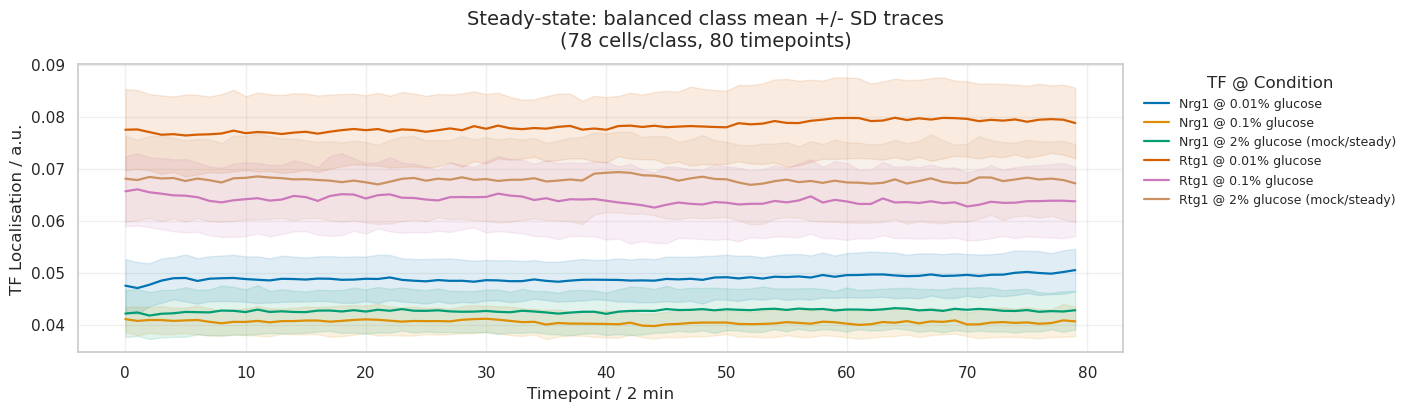

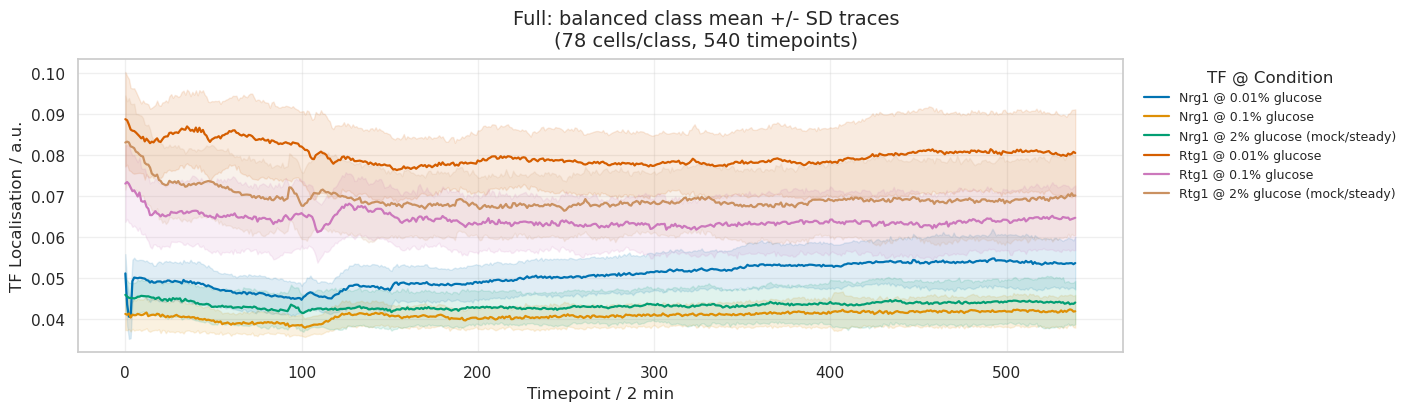

In [6]:
def plot_balanced_traces(d, dataset_tag, fig_path=None):
    'Mean +/- SD traces per class for the balanced (un-normalised) dataset.'
    X_bal       = d["X_bal"]
    y_bal       = d["y_bal"]
    class_names = d["class_names"]
    n_cls       = len(class_names)
    n_tp        = X_bal.shape[1]
    palette     = sns.color_palette("colorblind", n_colors=n_cls)

    fig, ax = plt.subplots(figsize=(14, 4), constrained_layout=True)
    for i, cls in enumerate(class_names):
        mask = y_bal == i
        mean = X_bal[mask].mean(axis=0)
        sd   = X_bal[mask].std(axis=0, ddof=1)
        ax.plot(np.arange(n_tp), mean, label=cls, color=palette[i], linewidth=1.6)
        ax.fill_between(np.arange(n_tp), mean - sd, mean + sd, color=palette[i], alpha=0.12)
    ax.set_xlabel("Timepoint / 2 min")
    ax.set_ylabel("TF Localisation / a.u.")
    ax.grid(alpha=0.3)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False,
              title="TF @ Condition", fontsize=9)
    fig.suptitle(f"{dataset_tag}: balanced class mean +/- SD traces\n"
                 f"({d['min_count']} cells/class, {n_tp} timepoints)", fontsize=14)
    if fig_path:
        fig.savefig(fig_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {fig_path}")
    plt.show()


plot_balanced_traces(ss,   "Steady-state")
plot_balanced_traces(full, "Full")


## 6. Raw KNN

In [7]:
def run_raw_knn(d, dataset_tag):
    'KNN on flat truncated (un-normalised) time series.'
    print(f"\n=== Raw KNN -- {dataset_tag} (T={d['min_T']}) ===")
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=K, n_jobs=-1)), # here we don't specify metric to be cosine, as it is NOT SimCLR embeddings
    ])
    pipe.fit(d["X_train_raw"], d["y_train"])
    y_pred = pipe.predict(d["X_test_raw"])
    acc    = accuracy_score(d["y_test"], y_pred)
    print(f"Accuracy: {acc:.4f}  (chance={1/len(d['class_names']):.4f})")
    print(classification_report(d["y_test"], y_pred, target_names=d["class_names"]))
    return acc, y_pred

ss_knn_acc,   ss_knn_pred   = run_raw_knn(ss,   "Steady-state")
full_knn_acc, full_knn_pred = run_raw_knn(full, "Full")



=== Raw KNN -- Steady-state (T=80) ===
Accuracy: 0.6383  (chance=0.1667)
                                 precision    recall  f1-score   support

           Nrg1 @ 0.01% glucose       0.68      0.87      0.76        15
            Nrg1 @ 0.1% glucose       0.65      0.73      0.69        15
Nrg1 @ 2% glucose (mock/steady)       0.50      0.38      0.43        16
           Rtg1 @ 0.01% glucose       0.62      1.00      0.76        16
            Rtg1 @ 0.1% glucose       0.62      0.62      0.62        16
Rtg1 @ 2% glucose (mock/steady)       1.00      0.25      0.40        16

                       accuracy                           0.64        94
                      macro avg       0.68      0.64      0.61        94
                   weighted avg       0.68      0.64      0.61        94


=== Raw KNN -- Full (T=540) ===
Accuracy: 0.7234  (chance=0.1667)
                                 precision    recall  f1-score   support

           Nrg1 @ 0.01% glucose       0.88      1.00

## 7. Catch22 + kNN

Features are length-agnostic — extracted from full-length series.

In [8]:
from features.catch22 import extract_catch22, fill_feature_frame

def run_catch22_knn(d, dataset_tag):
    'Catch22 features + kNN on full-length series.'
    print(f"\n=== Catch22 + kNN -- {dataset_tag} ===")
    X_tr = extract_catch22(list(d["X_train_raw"]), desc="Train")
    X_te = extract_catch22(list(d["X_test_raw"]),  desc="Test")
    X_tr, X_te = fill_feature_frame(X_tr, X_te)
    print(f"Feature matrix: {X_tr.shape[1]} features")
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn",    KNeighborsClassifier(n_neighbors=K, n_jobs=-1)),
    ])
    pipe.fit(X_tr, d["y_train"])
    y_pred = pipe.predict(X_te)
    acc    = accuracy_score(d["y_test"], y_pred)
    print(f"Accuracy: {acc:.4f}  (chance={1/len(d['class_names']):.4f})")
    print(classification_report(d["y_test"], y_pred, target_names=d["class_names"]))
    return acc, y_pred

ss_c22_acc,   ss_c22_pred   = run_catch22_knn(ss,   "Steady-state")
full_c22_acc, full_c22_pred = run_catch22_knn(full, "Full")


=== Catch22 + kNN -- Steady-state ===



Train:   0%|          | 0/374 [00:00<?, ?it/s]


Train:  77%|███████▋  | 288/374 [00:00<00:00, 2856.05it/s]


Test:   0%|          | 0/94 [00:00<?, ?it/s]

Feature matrix: 22 features


...


Train:  92%|█████████▏| 345/374 [00:01<00:00, 335.92it/s]


Test:   0%|          | 0/94 [00:00<?, ?it/s]


Test:  38%|███▊      | 36/94 [00:00<00:00, 358.45it/s]


Test:  78%|███████▊  | 73/94 [00:00<00:00, 361.26it/s]

Feature matrix: 22 features
Accuracy: 0.4149  (chance=0.1667)
                                 precision    recall  f1-score   support

           Nrg1 @ 0.01% glucose       0.54      0.47      0.50        15
            Nrg1 @ 0.1% glucose       0.55      0.80      0.65        15
Nrg1 @ 2% glucose (mock/steady)       0.31      0.31      0.31        16
           Rtg1 @ 0.01% glucose       0.43      0.56      0.49        16
            Rtg1 @ 0.1% glucose       0.23      0.19      0.21        16
Rtg1 @ 2% glucose (mock/steady)       0.33      0.19      0.24        16

                       accuracy                           0.41        94
                      macro avg       0.40      0.42      0.40        94
                   weighted avg       0.40      0.41      0.40        94



## 8. SimCLR Model Registry

In [ ]:
from utils.embeddings import load_simclr_model, encode_channel

NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}


from utils.embeddings import parse_arch_from_name as parse_arch


from functools import partial
from utils.embeddings import (
    make_checkpoint_short_label,
    make_unique_checkpoint_label,
)

make_short_label = partial(
    make_checkpoint_short_label,
    norm_overrides=NORM_OVERRIDES,
)
make_unique_label = partial(
    make_unique_checkpoint_label,
    norm_overrides=NORM_OVERRIDES,
)

CKPT_DIRS      = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]
MODEL_REGISTRY = []
for idx, _d in enumerate(CKPT_DIRS):
    for p in sorted((EXP_DIR / _d).glob("*.pth")):
        MODEL_REGISTRY.append({
            "path": p,
            "short_label": make_short_label(p),
            "label": make_unique_label(p, len(MODEL_REGISTRY)),
            "experiment": _d,
        })

EXP_COLOR_MAP = {
    "EXP-26-IY017": sns.color_palette("colorblind")[0],
    "EXP-26-IY022": sns.color_palette("colorblind")[1],
    "EXP-26-IY023": sns.color_palette("colorblind")[2],
    "EXP-26-IY024": sns.color_palette("colorblind")[4],
}

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
for row in MODEL_REGISTRY:
    arch = parse_arch(row["path"].name)
    print(f"  [{row['experiment']}]  {row['label']:<52s}  d_model={arch['d_model']}")


# KNN on RAW SimCLR embeddings with the Euclidean metric -- no StandardScaler.
# An ablation (raw vs StandardScaled x euclidean vs cosine, over all checkpoints)
# showed embedding scaling is a wash on average but homogenises checkpoints
# (collapsing several to identical accuracy) and suppresses the best ones;
# raw + euclidean gives the strongest, most faithful readout.

def run_simclr_knn(model, X_tr, X_te, y_tr, y_te, device):
    'Encode -> KNN on raw embeddings (Euclidean, no scaling); return (accuracy, y_pred).'
    Z_tr = encode_channel(model, X_tr, device)
    Z_te = encode_channel(model, X_te, device)
    neigh = KNeighborsClassifier(n_neighbors=K, n_jobs=-1)
    neigh.fit(Z_tr, y_tr)
    y_pred = neigh.predict(Z_te)
    return accuracy_score(y_te, y_pred), y_pred

Found 34 checkpoints:
  [EXP-26-IY017]  IY017-inst b100 D128 #00                              d_model=128
  [EXP-26-IY017]  IY017-inst b100 D128 #01                              d_model=128
  [EXP-26-IY017]  IY017-inst b1024 D16 164413                           d_model=16
  [EXP-26-IY017]  IY017-inst b1024 D16 061239                           d_model=16
  [EXP-26-IY017]  IY017-inst b128 D16 151037                            d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16 #05                                d_model=16
  [EXP-26-IY017]  IY017-inst b16 D16 #06                                d_model=16
  [EXP-26-IY017]  IY017-inst b2048 D16 162432                           d_model=16
  [EXP-26-IY017]  IY017-inst b256 D16 154425                            d_model=16
  [EXP-26-IY017]  IY017-inst b32 D128 #09                               d_model=128
  [EXP-26-IY017]  IY017-inst b4096 D16 140729                           d_model=16
  [EXP-26-IY017]  IY017-inst b4096 D16 023947                 

## 9. KNN Hyperparameter Grid Search

Grid search over **k ∈ {1, 3, 5, 7, 10, 15, 20}** with the **Euclidean** metric (sklearn default minkowski p=2) using 5-fold stratified CV on the SS training set, for all three methods (Raw KNN, Catch22+KNN, SimCLR+KNN), to pick the optimal k before running all 34 checkpoints in section 10.

Raw-trace and Catch22 features are StandardScaled (conventional input-feature scaling); **SimCLR embeddings are left raw** (`scale=False`), matching the raw + Euclidean evaluation in `run_simclr_knn`. A prior ablation (raw vs StandardScaled × euclidean vs cosine) showed embedding scaling is a wash on average but homogenises checkpoints and suppresses the best ones — so raw + Euclidean is used throughout.

The SimCLR grid search uses one representative checkpoint (first in registry) since the embedding geometry is determined by the training objective, not the specific checkpoint.

In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from features.catch22 import extract_catch22

K_GRID     = [1, 3, 5, 7, 10, 15, 20]
CV         = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
PARAM_GRID = {"knn__n_neighbors": K_GRID}  # search only k; metric stays sklearn default (minkowski p=2 = euclidean)


def run_knn_grid_search(X_tr, y_tr, label, scale=True):
    """GridSearchCV over k using an (optional StandardScaler) + KNN pipeline (5-fold stratified CV).

    scale=True for raw-trace/Catch22 input features (conventional feature
    scaling); scale=False for SimCLR embeddings, matching the raw+euclidean
    evaluation used in run_simclr_knn.
    """
    steps = ([("scaler", StandardScaler())] if scale else []) + [("knn", KNeighborsClassifier(n_jobs=-1))]
    pipe = Pipeline(steps)
    gs = GridSearchCV(pipe, PARAM_GRID, cv=CV, scoring="accuracy", n_jobs=-1)
    gs.fit(X_tr, y_tr)
    best_k = gs.best_params_["knn__n_neighbors"]
    print(f"  {label:<35s}  best k={best_k:>2d},  CV acc={gs.best_score_:.4f}")
    return best_k


# 1. Raw KNN (scale input features)
raw_best_k = run_knn_grid_search(ss["X_train_raw"], ss["y_train"], "Raw KNN (SS)")

# 2. Catch22 + KNN (scale input features)
X_tr_c22_df = extract_catch22(list(ss["X_train_raw"]), desc="Catch22 (grid search)")
X_tr_c22    = X_tr_c22_df.fillna(X_tr_c22_df.median()).fillna(0.0).values
c22_best_k  = run_knn_grid_search(X_tr_c22, ss["y_train"], "Catch22+KNN (SS)")

# 3. SimCLR + KNN — encode once with the first checkpoint as representative;
#    grid-search on RAW embeddings (scale=False) to match run_simclr_knn.
repr_model   = load_simclr_model(MODEL_REGISTRY[0]["path"], DEVICE)
Z_tr_repr    = encode_channel(repr_model, ss["X_train"], DEVICE)
simclr_best_k = run_knn_grid_search(Z_tr_repr, ss["y_train"],
                                     f"SimCLR+KNN ({MODEL_REGISTRY[0]['short_label']})", scale=False)

# Update the global K used by all subsequent KNN runs
print(f"\nK: {K} → {simclr_best_k}  (from SimCLR grid search)")
K = simclr_best_k

  Raw KNN (SS)                         best k=10,  CV acc=0.6817



Catch22 (grid search):   0%|          | 0/374 [00:00<?, ?it/s]


Catch22 (grid search):  79%|███████▉  | 297/374 [00:00<00:00, 2960.06it/s]

  Catch22+KNN (SS)                     best k=20,  CV acc=0.3476



SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]

  SimCLR+KNN (IY017-inst b100 D128)    best k=10,  CV acc=0.5990

K: 5 → 10  (from SimCLR grid search)


## 9. Run SimCLR Models

In [11]:
def run_all_models(d, dataset_name, csv_tag):
    'Evaluate all checkpoints; return results DataFrame and predictions dict.'
    rows, preds = [], {}
    n_cls  = len(d["class_names"])
    chance = 1.0 / n_cls
    print(f"  {n_cls} classes, chance={chance:.4f}")
    for row in MODEL_REGISTRY:
        ckpt_path = row["path"]
        print(f"  {row['label']:<55s}", end=" ")
        try:
            model = load_simclr_model(ckpt_path, DEVICE)
            acc, y_pred = run_simclr_knn(
                model,
                d["X_train"], d["X_test"],
                d["y_train"], d["y_test"],
                DEVICE
            )
            preds[str(ckpt_path)] = y_pred
            rows.append({
                "label":           row["label"],
                "short_label":     row["short_label"],
                "experiment":      row["experiment"],
                "checkpoint":      str(ckpt_path),
                "checkpoint_name": ckpt_path.name,
                "accuracy":        acc,
                "status":          "ok",
                "error":           "",
            })
            print(f"acc={acc:.4f}  (+{acc - chance:.4f})")
        except Exception as exc:
            rows.append({
                "label": row["label"], "short_label": row["short_label"],
                "experiment": row["experiment"],
                "checkpoint": str(ckpt_path), "checkpoint_name": ckpt_path.name,
                "accuracy": np.nan, "status": "failed", "error": str(exc),
            })
            print(f"FAILED: {exc}")

    results_df = (
        pd.DataFrame(rows)
        .sort_values("accuracy", ascending=False, na_position="last")
        .reset_index(drop=True)
    )
    csv_path = IY032_DIR / f"{csv_tag}_simclr_results.csv"
    results_df.to_csv(csv_path, index=False)
    print(f"\nSaved: {csv_path}")
    return results_df, preds


print("=" * 70)
print("STEADY-STATE dataset")
print("=" * 70)
ss_simclr_df,   ss_simclr_preds   = run_all_models(ss,   "ss",   "IY032_tf_condition_ss")

print()
print("=" * 70)
print("FULL dataset")
print("=" * 70)
full_simclr_df, full_simclr_preds = run_all_models(full, "full", "IY032_tf_condition_full")

STEADY-STATE dataset
  6 classes, chance=0.1667
  IY017-inst b100 D128 #00                                


SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]


SimCLR encode:   0%|          | 0/1 [00:00<?, ?it/s]

acc=0.6383  (+0.4716)
  IY017-inst b100 D128 #01                                


SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]

...


SimCLR encode:   0%|          | 0/1 [00:00<?, ?it/s]

acc=0.7128  (+0.5461)
  IY024-batch b64 D8 203126                               


SimCLR encode:   0%|          | 0/2 [00:00<?, ?it/s]


SimCLR encode:   0%|          | 0/1 [00:00<?, ?it/s]

acc=0.7766  (+0.6099)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY032/IY032_tf_condition_full_simclr_results.csv


## 10. Results Comparison

- **SimCLR bar chart** with Raw kNN & Catch22+kNN as reference lines
- **Summary** grouped bar: Raw kNN vs Catch22+kNN vs best SimCLR
- **Confusion matrices**: 3 methods × 2 datasets (SS and Full)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY032/IY032_tf_condition_ss_simclr_results.png


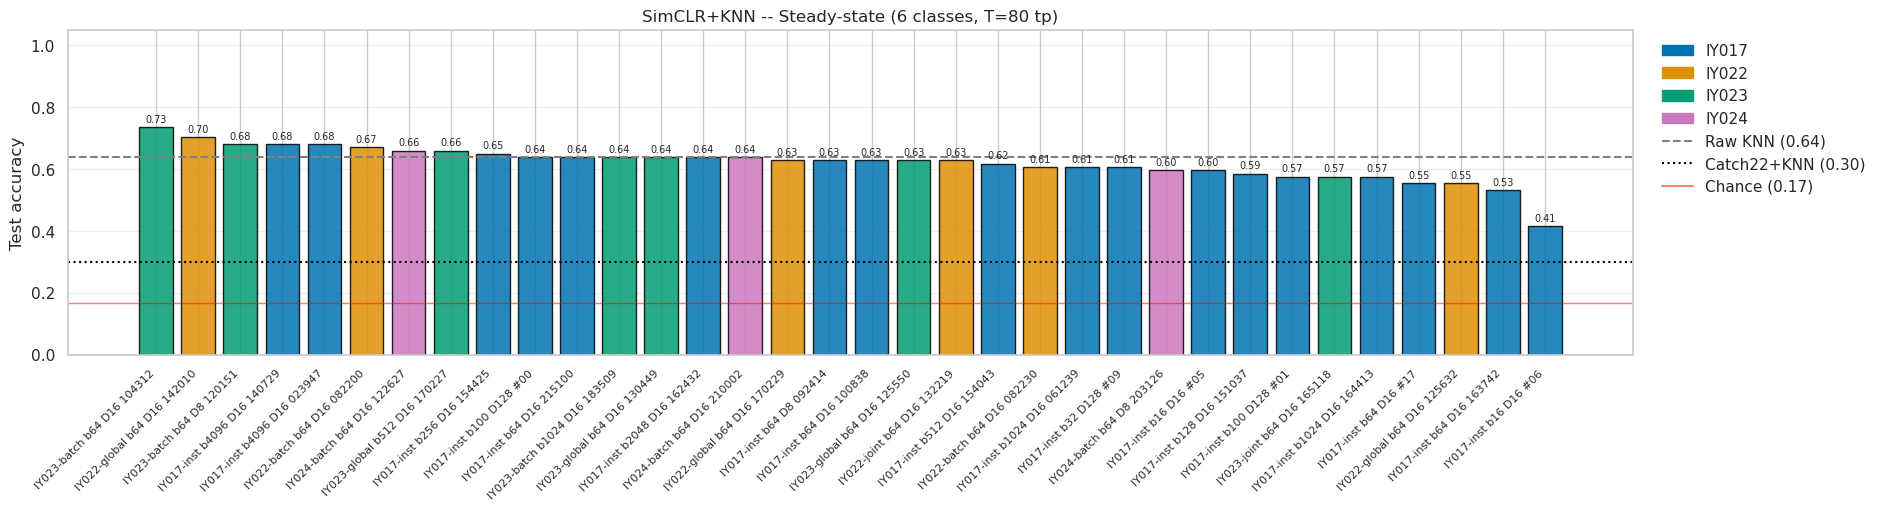

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY032/IY032_tf_condition_full_simclr_results.png


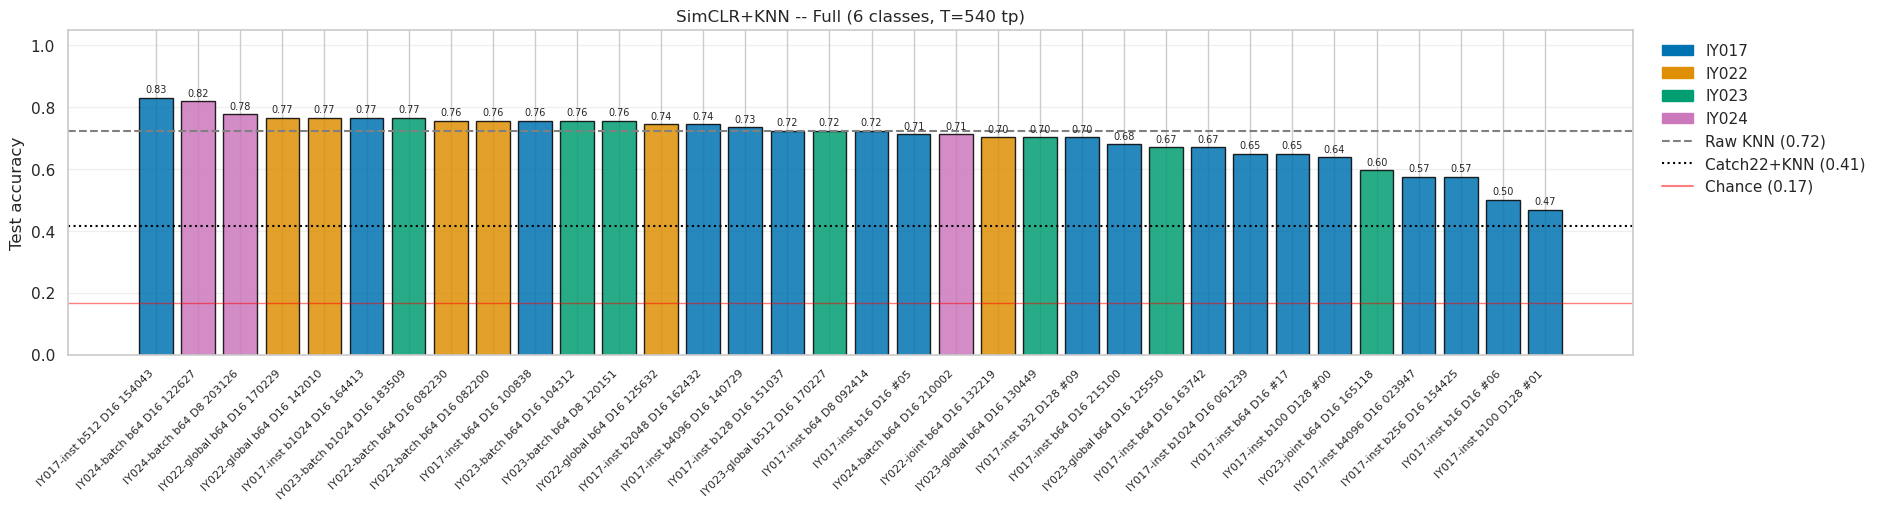

Saved: IY032_tf_condition_summary_comparison.png


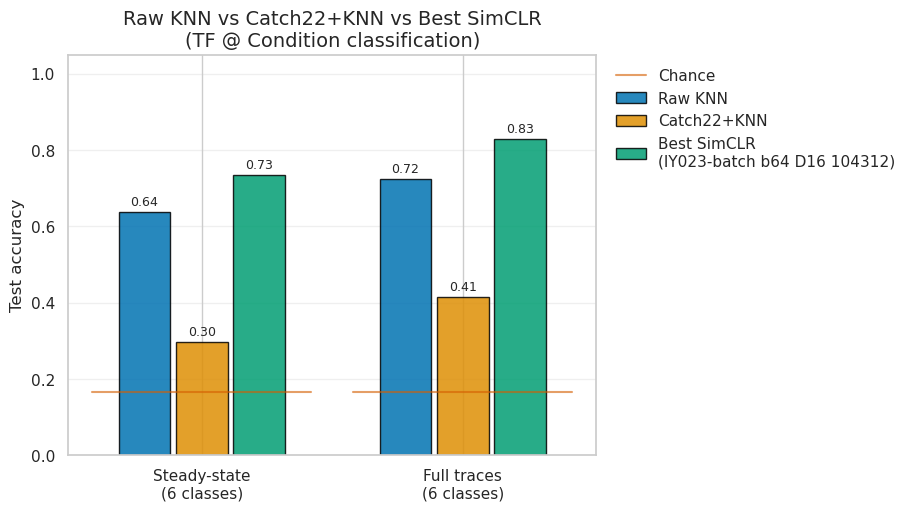


Best SimCLR -- SS:   IY023-batch b64 D16 104312  acc=0.7340
Best SimCLR -- Full: IY017-inst b512 D16 154043  acc=0.8298


Saved: IY032_tf_condition_confusion_matrices.png


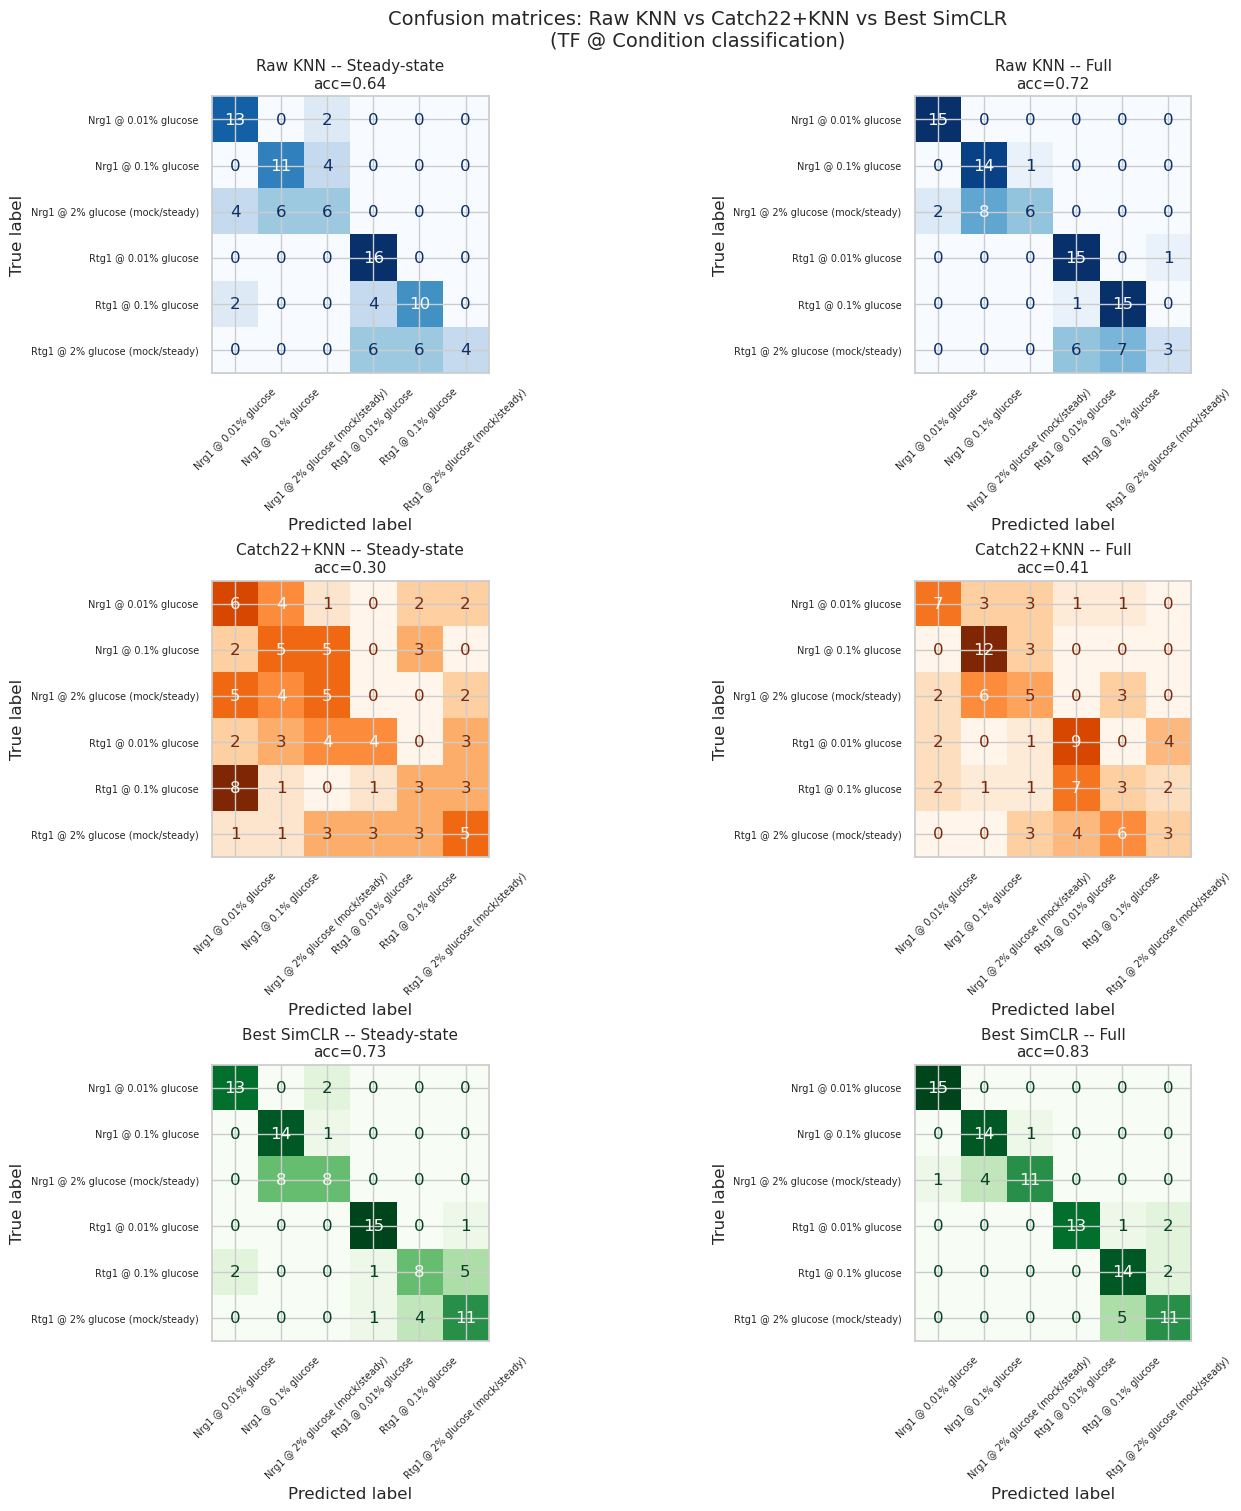

In [12]:
# ── SimCLR bar charts with Raw KNN & Catch22 as reference lines ─────────────
ss_simclr_valid   = ss_simclr_df[ss_simclr_df["status"] == "ok"]
full_simclr_valid = full_simclr_df[full_simclr_df["status"] == "ok"]


def plot_simclr_bar(valid, d, dataset_tag, knn_acc, c22_acc, fig_path):
    'All-checkpoint bar chart with baselines drawn as reference lines.'
    n_cls  = len(d["class_names"])
    chance = 1.0 / n_cls
    bar_colors = [EXP_COLOR_MAP.get(exp, (0.5,) * 3) for exp in valid["experiment"]]
    fig, ax = plt.subplots(figsize=(max(14, len(valid) * 0.55), 5), constrained_layout=True)
    bars = ax.bar(range(len(valid)), valid["accuracy"],
                  color=bar_colors, alpha=0.85, edgecolor="black")
    ax.axhline(knn_acc, color="grey",  linestyle="--", lw=1.5,
               label=f"Raw KNN ({knn_acc:.2f})")
    ax.axhline(c22_acc, color="black", linestyle=":",  lw=1.5,
               label=f"Catch22+KNN ({c22_acc:.2f})")
    ax.axhline(chance,  color="red",   linestyle="-",  lw=1.0, alpha=0.5,
               label=f"Chance ({chance:.2f})")
    ax.set_xticks(range(len(valid)))
    ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Test accuracy")
    ax.set_title(f"SimCLR+KNN -- {dataset_tag} ({n_cls} classes, T={d['min_T']} tp)")
    ax.grid(axis="y", alpha=0.3)
    for bar, acc in zip(bars, valid["accuracy"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{acc:.2f}", ha="center", va="bottom", fontsize=7)
    palette = sns.color_palette("colorblind")
    legend_handles = [
        Patch(color=EXP_COLOR_MAP.get(_d, palette[7]), label=_d.replace("EXP-26-", ""))
        for _d in CKPT_DIRS
    ] + [
        plt.Line2D([0], [0], color="grey",  ls="--", label=f"Raw KNN ({knn_acc:.2f})"),
        plt.Line2D([0], [0], color="black", ls=":",  label=f"Catch22+KNN ({c22_acc:.2f})"),
        plt.Line2D([0], [0], color="red",   ls="-",  alpha=0.5, label=f"Chance ({chance:.2f})"),
    ]
    ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    plt.show()


plot_simclr_bar(ss_simclr_valid,   ss,   "Steady-state",
                ss_knn_acc,   ss_c22_acc,
                IY032_DIR / "IY032_tf_condition_ss_simclr_results.png")
plot_simclr_bar(full_simclr_valid, full, "Full",
                full_knn_acc, full_c22_acc,
                IY032_DIR / "IY032_tf_condition_full_simclr_results.png")


# ── Summary: Raw KNN vs Catch22+KNN vs best SimCLR ──────────────────────────
ss_best   = ss_simclr_valid.iloc[0]
full_best = full_simclr_valid.iloc[0]
ss_chance   = 1.0 / len(ss["class_names"])
full_chance = 1.0 / len(full["class_names"])

palette = sns.color_palette("colorblind")
methods = ["Raw KNN", "Catch22+KNN", f"Best SimCLR\n({ss_best['label']})"]
x       = np.arange(2)
width   = 0.22

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
for i, (ss_val, full_val) in enumerate(zip(
    [ss_knn_acc,   ss_c22_acc,   ss_best["accuracy"]],
    [full_knn_acc, full_c22_acc, full_best["accuracy"]],
)):
    bars = ax.bar(x + (i - 1) * width, [ss_val, full_val], width=width * 0.9,
                  label=methods[i], color=palette[i], alpha=0.85, edgecolor="black")
    for bar, v in zip(bars, [ss_val, full_val]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{v:.2f}", ha="center", va="bottom", fontsize=9)

ax.plot(x[0] + np.array([-0.42, 0.42]), [ss_chance,   ss_chance],   "r-", lw=1.5, alpha=0.6, label="Chance")
ax.plot(x[1] + np.array([-0.42, 0.42]), [full_chance, full_chance], "r-", lw=1.5, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f"Steady-state\n({len(ss['class_names'])} classes)",
                    f"Full traces\n({len(full['class_names'])} classes)"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test accuracy")
ax.set_title("Raw KNN vs Catch22+KNN vs Best SimCLR\n(TF @ Condition classification)", fontsize=14)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
ax.grid(axis="y", alpha=0.3)
fig.savefig(IY032_DIR / "IY032_tf_condition_summary_comparison.png", dpi=150, bbox_inches="tight")
print(f"Saved: IY032_tf_condition_summary_comparison.png")
plt.show()

print(f"\nBest SimCLR -- SS:   {ss_best['label']}  acc={ss_best['accuracy']:.4f}")
print(f"Best SimCLR -- Full: {full_best['label']}  acc={full_best['accuracy']:.4f}")


# ── Confusion matrices: 3 methods x 2 datasets ──────────────────────────────
n_cls_max = max(len(ss["class_names"]), len(full["class_names"]))
cm_h      = max(5, n_cls_max * 0.5 + 2)

fig, axes = plt.subplots(3, 2, figsize=(7 * 2, cm_h * 3), constrained_layout=True)
cm_entries = [
    (axes[0, 0], ss,   "Raw KNN",       ss_knn_pred,                              "Steady-state"),
    (axes[0, 1], full, "Raw KNN",       full_knn_pred,                            "Full"),
    (axes[1, 0], ss,   "Catch22+KNN",   ss_c22_pred,                              "Steady-state"),
    (axes[1, 1], full, "Catch22+KNN",   full_c22_pred,                            "Full"),
    (axes[2, 0], ss,   "Best SimCLR",   ss_simclr_preds[ss_best["checkpoint"]],   "Steady-state"),
    (axes[2, 1], full, "Best SimCLR",   full_simclr_preds[full_best["checkpoint"]], "Full"),
]
cm_palette = {"Raw KNN": "Blues", "Catch22+KNN": "Oranges", "Best SimCLR": "Greens"}
for ax, d, method, y_pred, dataset_tag in cm_entries:
    acc = accuracy_score(d["y_test"], y_pred)
    ConfusionMatrixDisplay.from_predictions(
        d["y_test"], y_pred,
        display_labels=d["class_names"],
        ax=ax, colorbar=False, cmap=cm_palette[method], xticks_rotation=45,
    )
    ax.set_title(f"{method} -- {dataset_tag}\nacc={acc:.2f}", fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Confusion matrices: Raw KNN vs Catch22+KNN vs Best SimCLR\n"
             "(TF @ Condition classification)", fontsize=14)
fig.savefig(IY032_DIR / "IY032_tf_condition_confusion_matrices.png", dpi=150, bbox_inches="tight")
print(f"Saved: IY032_tf_condition_confusion_matrices.png")
plt.show()